In [ ]:
!pip -q install networkx

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving TNBC_PPI_Network.gml to TNBC_PPI_Network.gml


In [ ]:
G = nx.read_gml("TNBC_PPI_Network.gml")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 27
Edges: 49


In [ ]:
degree = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

In [ ]:
hub_genes = pd.DataFrame({
    "Gene": list(degree.keys()),
    "Degree Centrality": list(degree.values()),
    "Betweenness Centrality": list(betweenness.values()),
    "Closeness Centrality": list(closeness.values()),
    "Eigenvector Centrality": list(eigenvector.values())
})

In [ ]:
hub_genes = hub_genes.sort_values(
    by="Degree Centrality",
    ascending=False
)

hub_genes.head(20)

,Gene,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
1,ESR1,0.576923,0.328125,0.584881,4.335663e-01
7,FOXA1,0.423077,0.079099,0.513986,4.158964e-01
5,GATA3,0.346154,0.104147,0.513986,3.561266e-01
16,ERBB2,0.346154,0.122110,0.513986,3.483985e-01
6,AGR2,0.192308,0.015077,0.394454,2.133102e-01
18,AR,0.192308,0.015846,0.434911,2.567932e-01
4,XBP1,0.153846,0.002088,0.413696,2.157637e-01
13,FOXC1,0.153846,0.000000,0.424038,2.363062e-01
14,GRB7,0.153846,0.016821,0.424038,1.947108e-01
3,SOX10,0.153846,0.120000,0.368729,1.123280e-01


In [ ]:
hub_genes.to_csv("Hub_Genes.csv", index=False)

print("Hub gene table saved successfully.")

Hub gene table saved successfully.


In [ ]:
hub_genes.head(20)

,Gene,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
1,ESR1,0.576923,0.328125,0.584881,4.335663e-01
7,FOXA1,0.423077,0.079099,0.513986,4.158964e-01
5,GATA3,0.346154,0.104147,0.513986,3.561266e-01
16,ERBB2,0.346154,0.122110,0.513986,3.483985e-01
6,AGR2,0.192308,0.015077,0.394454,2.133102e-01
18,AR,0.192308,0.015846,0.434911,2.567932e-01
4,XBP1,0.153846,0.002088,0.413696,2.157637e-01
13,FOXC1,0.153846,0.000000,0.424038,2.363062e-01
14,GRB7,0.153846,0.016821,0.424038,1.947108e-01
3,SOX10,0.153846,0.120000,0.368729,1.123280e-01


In [ ]:
top10 = hub_genes.head(10)

top10.to_csv(
    "Top10_Hub_Genes.csv",
    index=False
)

top10

,Gene,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
1,ESR1,0.576923,0.328125,0.584881,0.433566
7,FOXA1,0.423077,0.079099,0.513986,0.415896
5,GATA3,0.346154,0.104147,0.513986,0.356127
16,ERBB2,0.346154,0.122110,0.513986,0.348398
6,AGR2,0.192308,0.015077,0.394454,0.213310
18,AR,0.192308,0.015846,0.434911,0.256793
4,XBP1,0.153846,0.002088,0.413696,0.215764
13,FOXC1,0.153846,0.000000,0.424038,0.236306
14,GRB7,0.153846,0.016821,0.424038,0.194711
3,SOX10,0.153846,0.120000,0.368729,0.112328


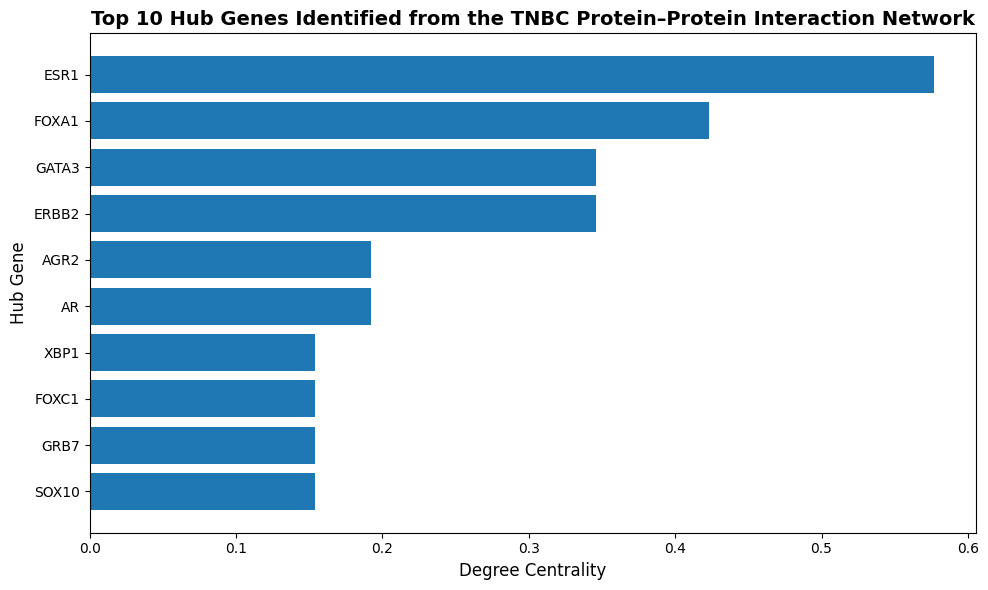

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["Gene"],
    top10["Degree Centrality"]
)

plt.gca().invert_yaxis()

plt.xlabel("Degree Centrality", fontsize=12)

plt.ylabel("Hub Gene", fontsize=12)

plt.title(
    "Top 10 Hub Genes Identified from the TNBC Protein–Protein Interaction Network",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure14_Top_Hub_Genes.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()